# Proyecto 1 — Competencia de modelación con MLP

**Curso:** CC3092 Deep Learning y sistemas inteligentes  
**Estudiante:** Ian Cumes — 23236  
**Dataset:** `train.csv` suministrado por el curso  
**Modo de ejecución registrado:** `full`

## tl;dr

Se entrenó un MLP de regresión con preprocesamiento ajustado exclusivamente dentro de cada partición. El modelo individual obtuvo **USD 24,460 de RMSE** en el test interno aislado; el ensemble predefinido de cinco semillas obtuvo **USD 22,386**. La configuración se eligió antes de consultar ese test. Estos valores son evidencia interna, no una promesa sobre el held-out del curso.


## Contexto y método

El objetivo es minimizar RMSE en dólares para un archivo held-out sin `SalePrice`. Solo se utilizó el dataset entregado; no se consultaron etiquetas públicas de los 292 `Id` ausentes. `Id` se conserva para trazabilidad, pero no entra al MLP.

### Supuestos clave

- La unidad de análisis es una vivienda vendida.
- El held-out conserva las mismas 80 features.
- El test interno del 20% permanece fuera de selección y se consulta una sola vez.
- El ensemble es un artefacto opcional y solo debe emplearse si el profesor lo autoriza.


In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import Image, display

ROOT = Path.cwd()
RESULTS = ROOT / "results"
FIGURES = RESULTS / "figures"
assert (ROOT / "train.csv").exists(), "Ejecute el notebook desde la raíz del repositorio."

data = pd.read_csv(ROOT / "train.csv")
quality = json.loads((RESULTS / "data_quality.json").read_text(encoding="utf-8"))
experiments = pd.read_csv(RESULTS / "experiments.csv")
final_metrics = json.loads((RESULTS / "final_metrics.json").read_text(encoding="utf-8"))
print(f"Dataset: {data.shape[0]:,} filas × {data.shape[1]} columnas")
print(f"Huella SHA-256: {final_metrics['data_sha256']}")


Dataset: 1,168 filas × 81 columnas
Huella SHA-256: 5de40f6319f30de0e577716b1253488dad117000659e7c3944e425c2bbdac641


## 2.1 Análisis exploratorio de datos (EDA)

La auditoría cubre dimensiones, tipos, unicidad, nulos, consistencia y outliers. Los nulos de elementos físicos ausentes se codifican como `None`; el resto se imputa dentro de cada fold. No se eliminan masivamente outliers con IQR porque varias variables son cero-infladas.


In [2]:
profile = pd.DataFrame({
    "Métrica": ["Filas", "Features numéricas", "Features categóricas", "Filas duplicadas", "Id duplicados", "Celdas nulas", "Columnas con nulos", "Asimetría SalePrice", "Asimetría log1p(SalePrice)"],
    "Valor": [quality["clean"]["rows"], quality["clean"]["numeric_features"], quality["clean"]["categorical_features"], quality["clean"]["duplicate_rows"], quality["clean"]["duplicate_ids"], quality["clean"]["total_missing"], quality["clean"]["columns_with_missing"], round(quality["clean"]["target_skew"], 3), round(quality["clean"]["log_target_skew"], 3)]
})
display(profile)
display(data[["SalePrice", "OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "YearBuilt"]].describe().T)
display(pd.DataFrame(quality["raw"]["extreme_living_area"]))
print("Categorías con apóstrofos antes de limpiar:", quality["raw"]["remaining_wrapped_apostrophes"])
print("Categorías con apóstrofos después de limpiar:", quality["clean"]["remaining_wrapped_apostrophes"])


,Métrica,Valor
0,Filas,1168.000
1,Features numéricas,37.000
2,Features categóricas,43.000
3,Filas duplicadas,0.000
4,Id duplicados,0.000
5,Celdas nulas,288.000
6,Columnas con nulos,4.000
7,Asimetría SalePrice,1.743
8,Asimetría log1p(SalePrice),0.125


,count,mean,std,min,25%,50%,75%,max
SalePrice,1168.0,181441.541952,77263.583862,34900.0,130000.00,165000.0,214925.00,745000.0
OverallQual,1168.0,6.121575,1.367619,1.0,5.00,6.0,7.00,10.0
GrLivArea,1168.0,1527.401541,524.432686,334.0,1145.75,1473.0,1792.00,5642.0
GarageCars,1168.0,1.781678,0.740161,0.0,1.00,2.0,2.00,4.0
TotalBsmtSF,1168.0,1061.771404,440.676330,0.0,796.00,997.5,1299.25,6110.0
YearBuilt,1168.0,1970.965753,30.675495,1872.0,1953.00,1972.0,2001.00,2010.0


,Id,GrLivArea,SalePrice
0,1183,4476,745000
1,524,4676,184750
2,1299,5642,160000


Categorías con apóstrofos antes de limpiar: 380
Categorías con apóstrofos después de limpiar: 0


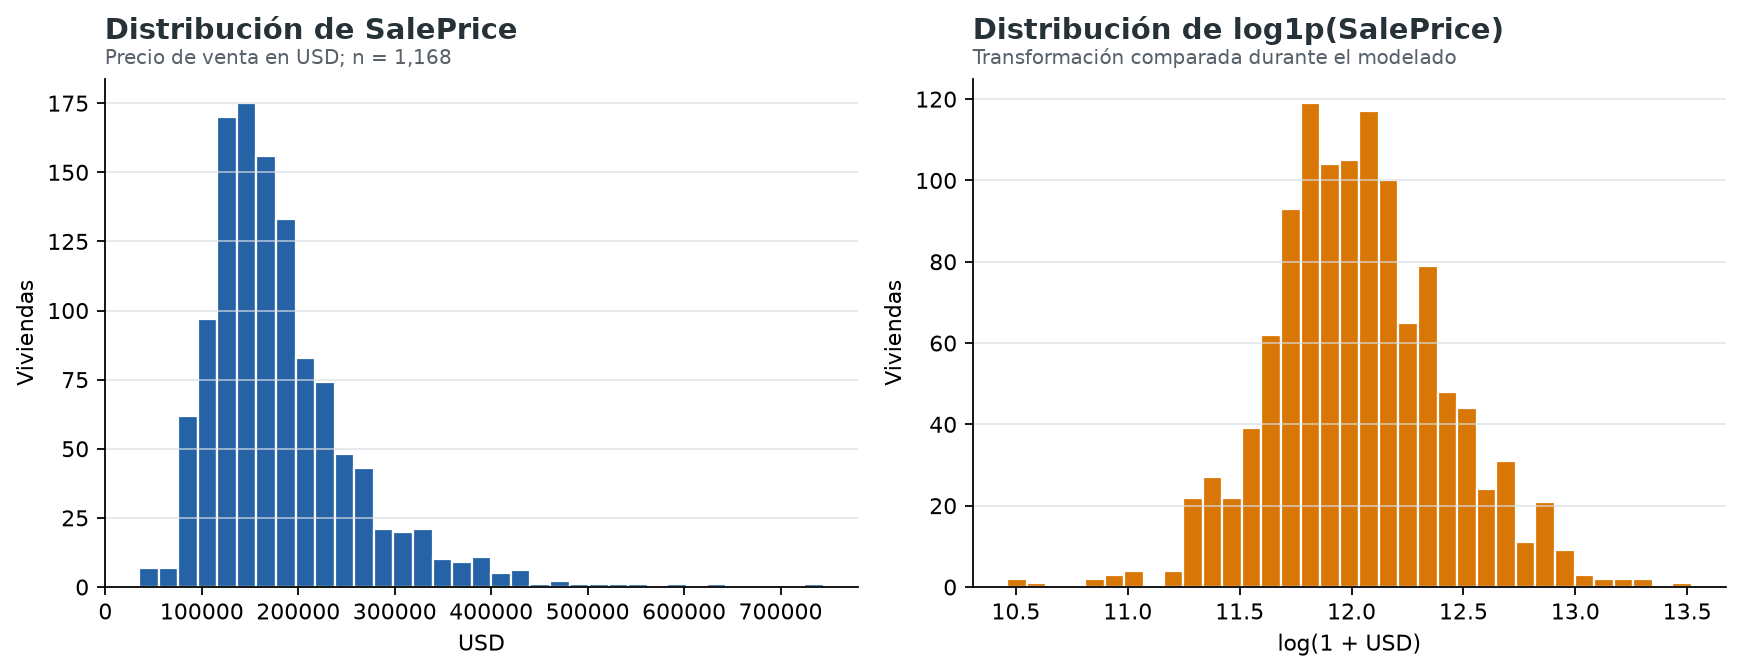

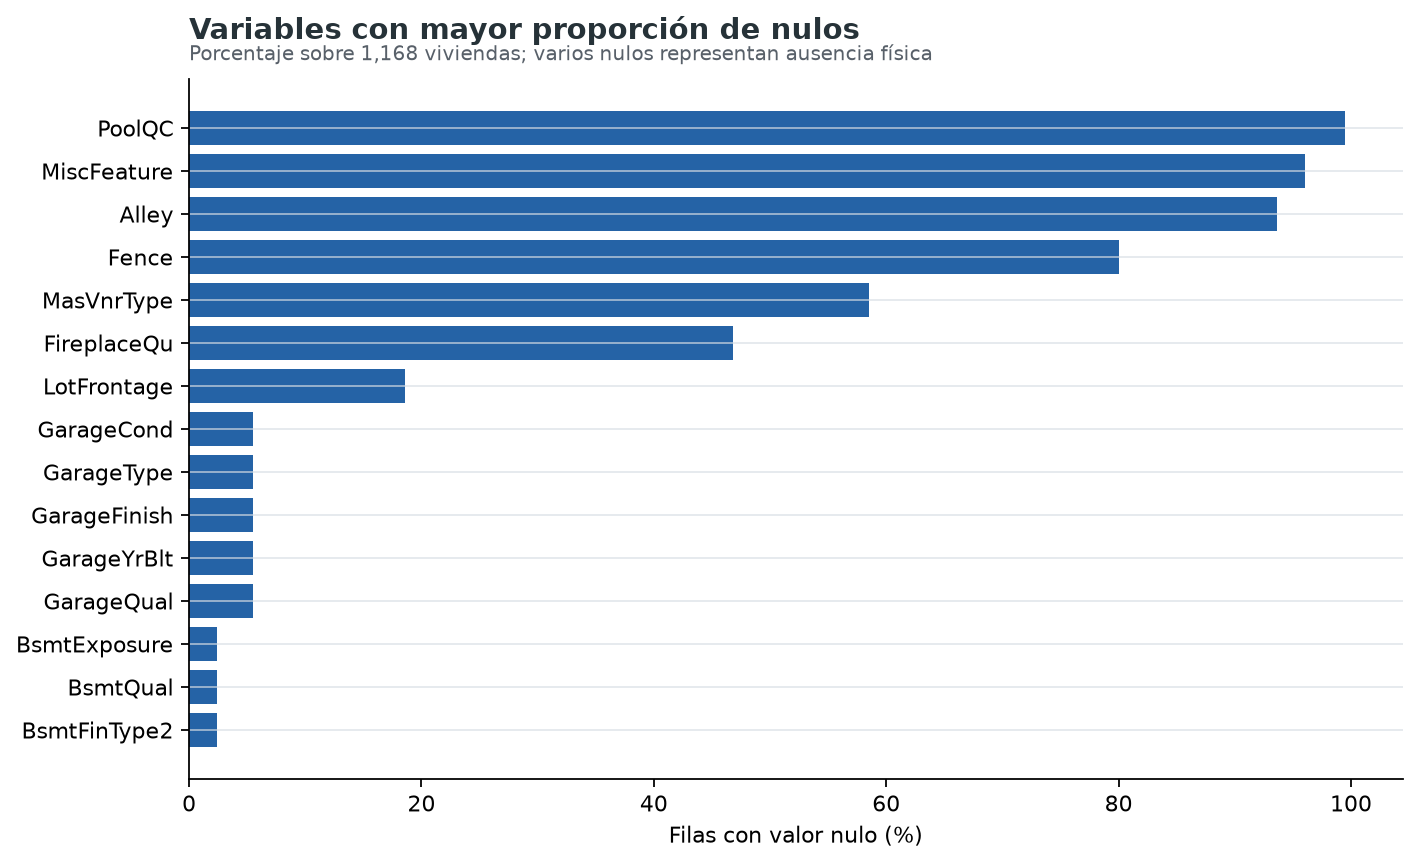

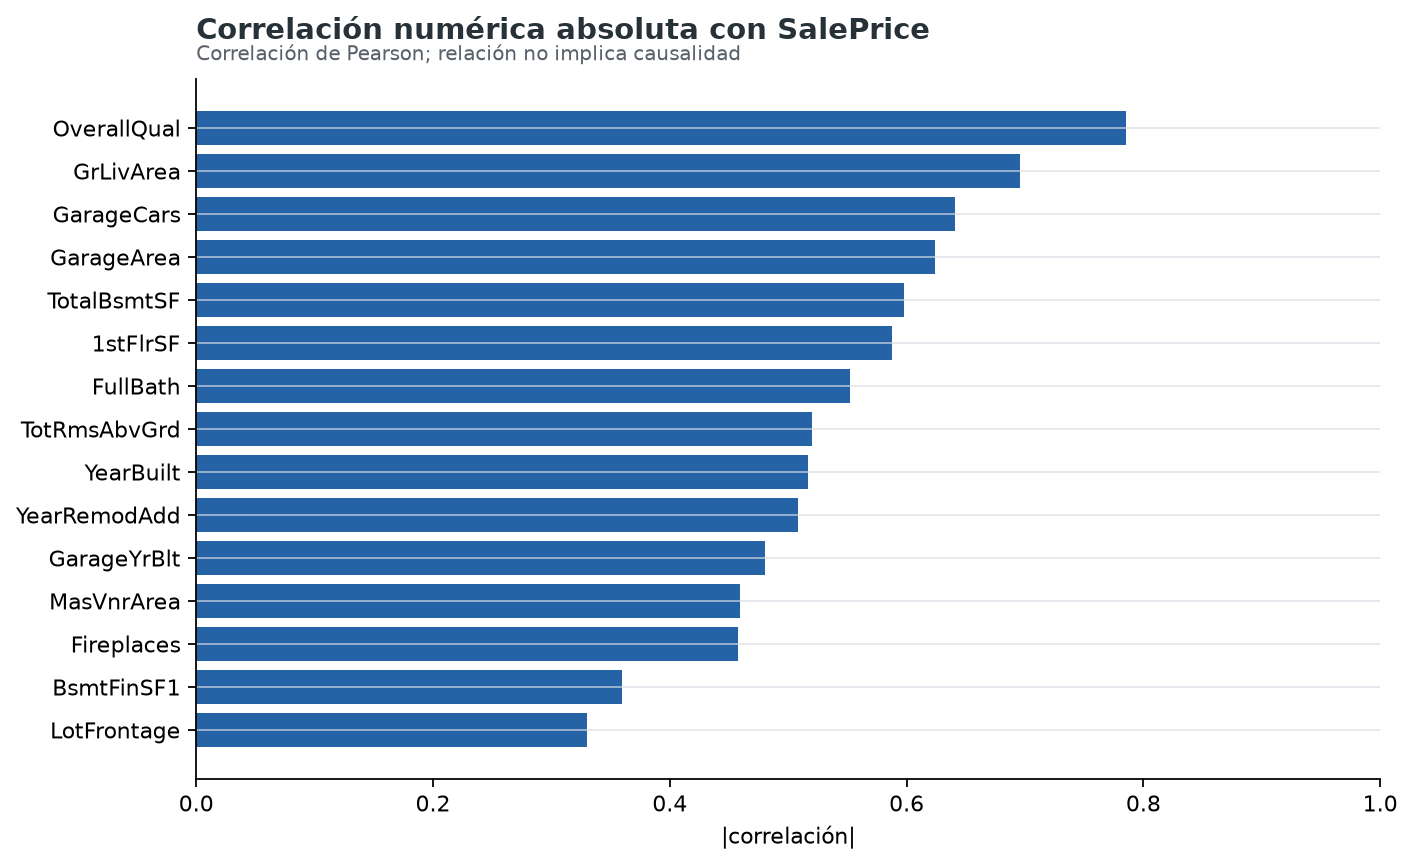

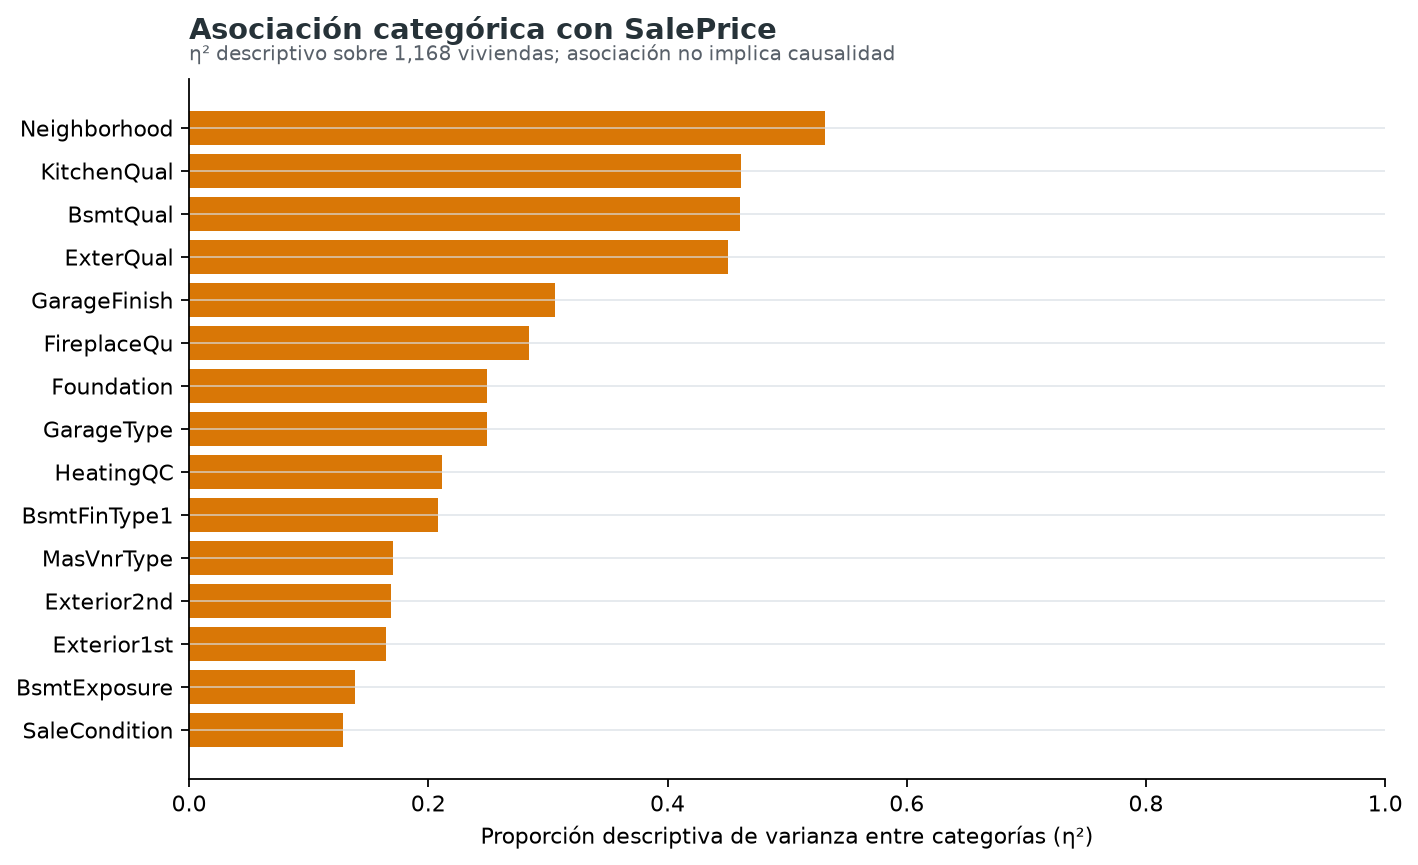

In [3]:
for figure in ["target_distribution.png", "missingness.png", "correlations.png"]:
    display(Image(filename=str(FIGURES / figure)))
display(Image(filename=str(FIGURES / "categorical_associations.png")))


### Decisiones derivadas del EDA

- `SalePrice` presenta cola derecha; se compara target estandarizado directo contra `log1p`.
- Las variables categóricas requieren manejo explícito de categorías desconocidas.
- La ausencia de garaje, sótano o piscina es información, no un error de captura.
- Los casos extremos se conservan por defecto y se compara winsorización ajustada solo con entrenamiento.


## 2.2 Metodología de desarrollo

Se separó un test interno estratificado del 20%. Sobre el 80% restante se ejecutaron baselines, diez ablaciones y **183 trials acumulados de Optuna** con validación cruzada de tres folds (120 completos y 63 podados). Los finalistas se reevaluaron con cinco folds y dos semillas. Cada fold ajusta su propio imputador, encoder, escalador y transformación del target.

El MLP permite 1–4 capas, cinco activaciones, BatchNorm, Dropout, MSE o SmoothL1, cuatro optimizadores, scheduler, weight decay, clipping de gradiente y early stopping. La salida es lineal y todas las métricas se calculan después de volver a dólares.


In [4]:
selected = final_metrics["selected_candidate"]
print("Configuración seleccionada:")
display(pd.json_normalize(selected).T.rename(columns={0: "valor"}))
print("Épocas finales:", final_metrics["final_epochs"])


Configuración seleccionada:


,valor
name,T109
preprocess.numeric_only,False
preprocess.scaler,standard
preprocess.encoding,onehot
preprocess.feature_engineering,True
preprocess.add_log_features,False
preprocess.winsorize,False
preprocess.min_frequency,None
preprocess.target_transform,log1p
model.hidden_layers,"[512, 128, 128]"


Épocas finales: 12


## 2.3 Resultados de iteraciones

La tabla conserva baselines, cambios controlados y finalistas. El RMSE de validación es la métrica de selección; el test interno no aparece en esta tabla para evitar mezclar selección con evaluación final.


,id,stage,train_rmse,val_rmse,val_mae,val_r2,best_epoch
12,F_T109,finalist,—,"26,681","15,883",0.877,12
13,F_T171,finalist,—,"26,970","17,140",0.876,17
14,F_T115,finalist,—,"27,718","16,960",0.868,16
10,A09_smooth_l1,ablation,"30,697","35,097","20,053",0.849,2
4,A03_target_log,ablation,"14,019","35,453","18,055",0.846,12
8,A07_gelu_adamw,ablation,"34,860","38,586","23,515",0.817,1
9,A08_dropout_sin_bn,ablation,"27,448","38,826","19,377",0.815,3
1,B02_Ridge,baseline,"20,853","40,001","21,764",0.804,0
2,A01_numerico,ablation,"32,952","40,121","24,463",0.803,3
3,A02_onehot_base,ablation,"22,311","40,561","20,278",0.798,4


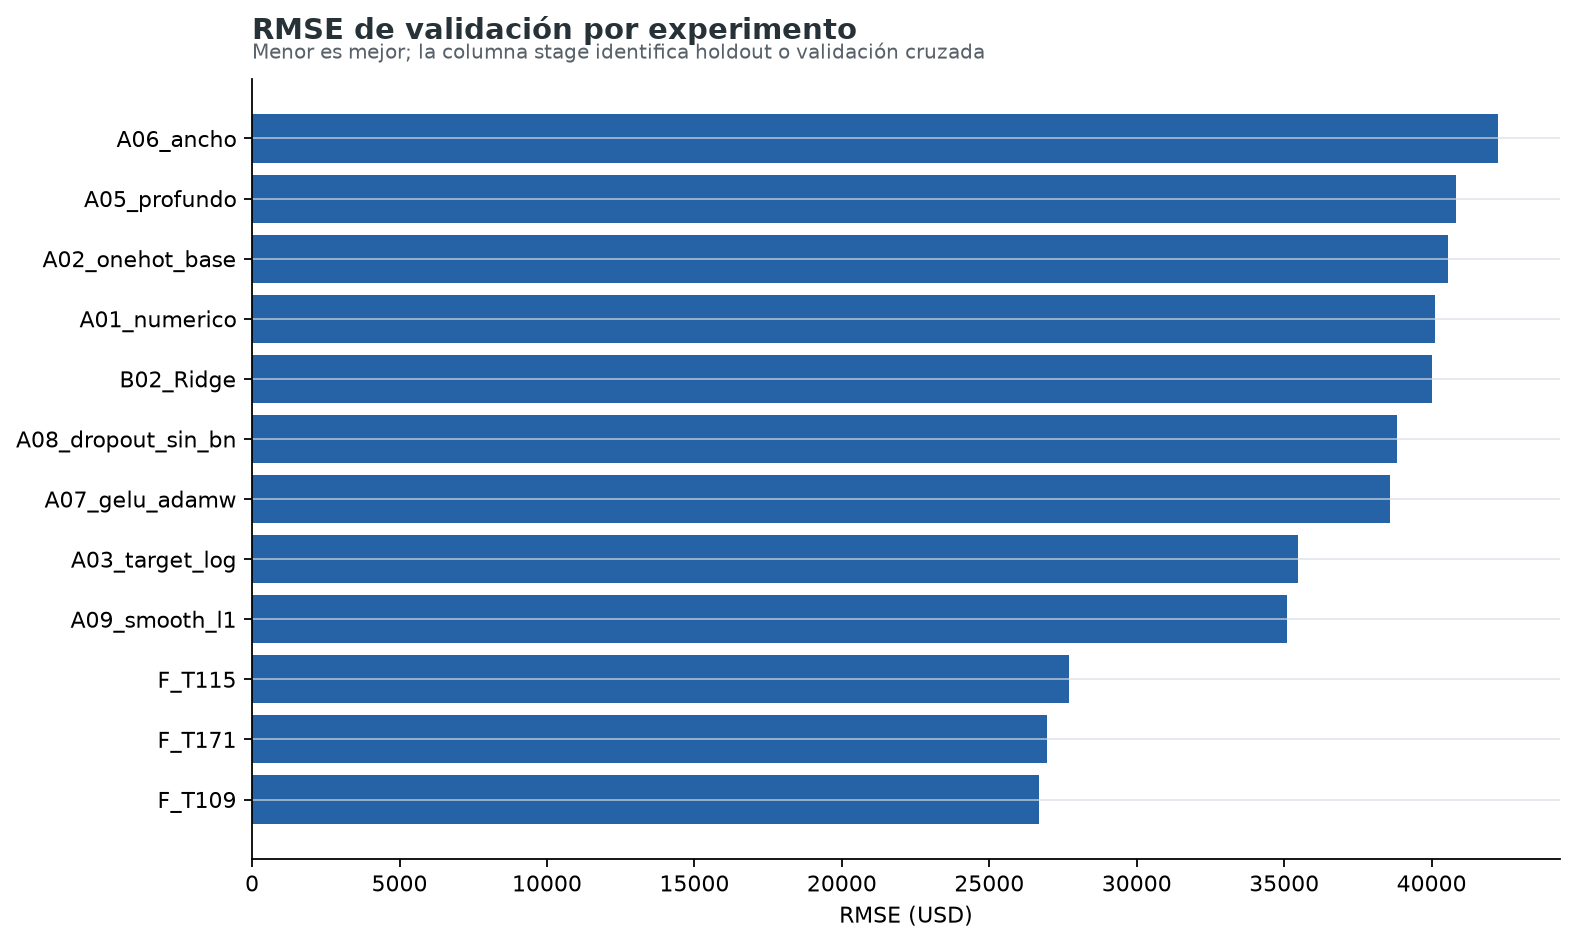

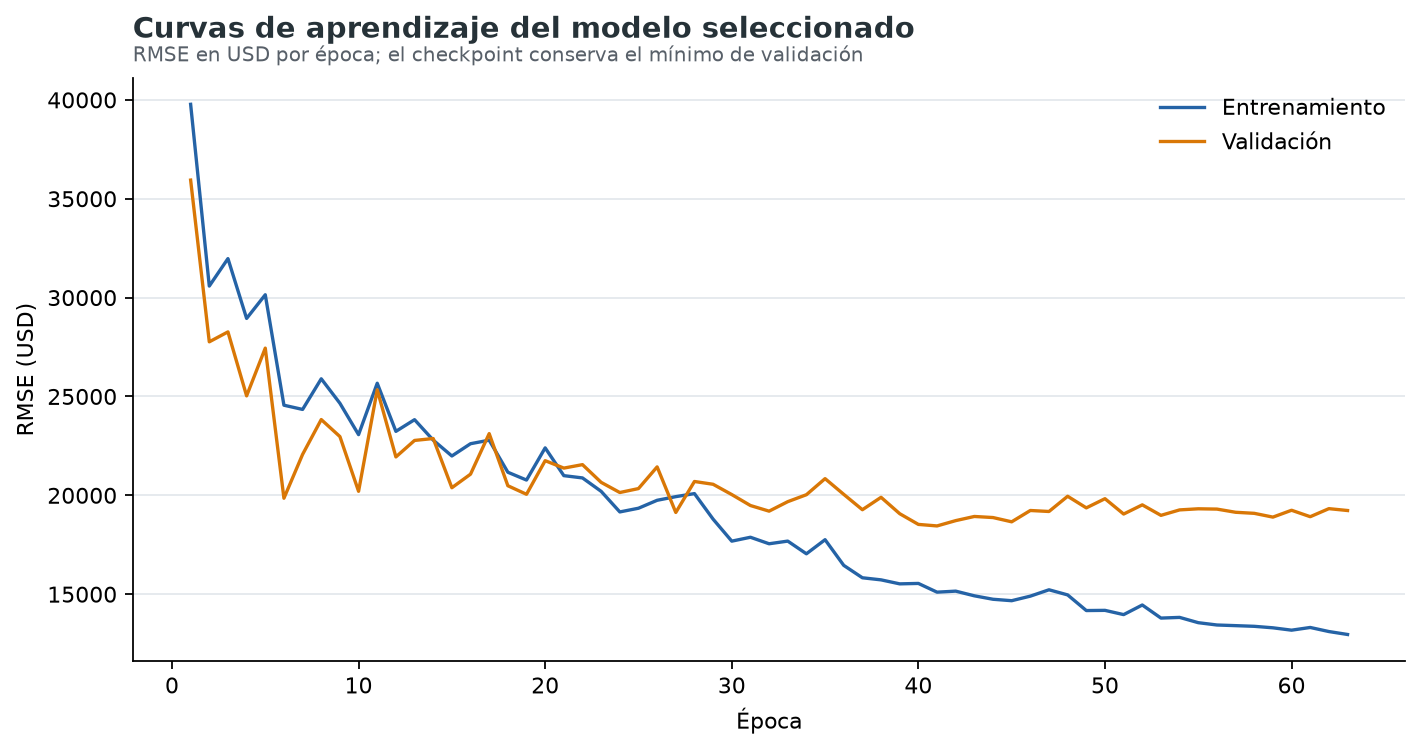

In [5]:
columns = [c for c in ["id", "stage", "train_rmse", "val_rmse", "val_mae", "val_r2", "best_epoch"] if c in experiments]
display(experiments[columns].sort_values("val_rmse", na_position="last").head(20).style.format({
    "train_rmse": "{:,.0f}", "val_rmse": "{:,.0f}", "val_mae": "{:,.0f}", "val_r2": "{:.3f}"
}, na_rep="—"))
display(Image(filename=str(FIGURES / "experiment_comparison.png")))
display(Image(filename=str(FIGURES / "learning_curve.png")))


## 2.4 Discusión de resultados

El test interno contiene 234 viviendas. El MLP individual obtuvo RMSE USD 24,460, MAE USD 16,131 y R² 0.887. El ensemble obtuvo RMSE USD 22,386, MAE USD 14,182 y R² 0.905.

El ensemble redujo el RMSE interno en **8.5%** frente al modelo individual. El mayor error absoluto individual fue la vivienda `Id=1325`: precio real USD 147,000, predicción USD 302,281 y error absoluto USD 155,281. El RMSE del cuartil de precios altos fue USD 33,585, evidencia de que los casos caros dominan parte importante del error cuadrático.

El gráfico de residuos permite comprobar heterocedasticidad y errores en precios altos. Dado el tamaño reducido del dataset, la incertidumbre entre folds y semillas importa: una mejora pequeña no debe interpretarse como universal. El MLP también puede quedar por debajo de métodos de boosting en datos tabulares; Ridge se conserva como control, no como candidato de competencia.


,rmse,mae,r2
rows,234,234,234.000
single,"24,460","16,131",0.887
ensemble,"22,386","14,182",0.905


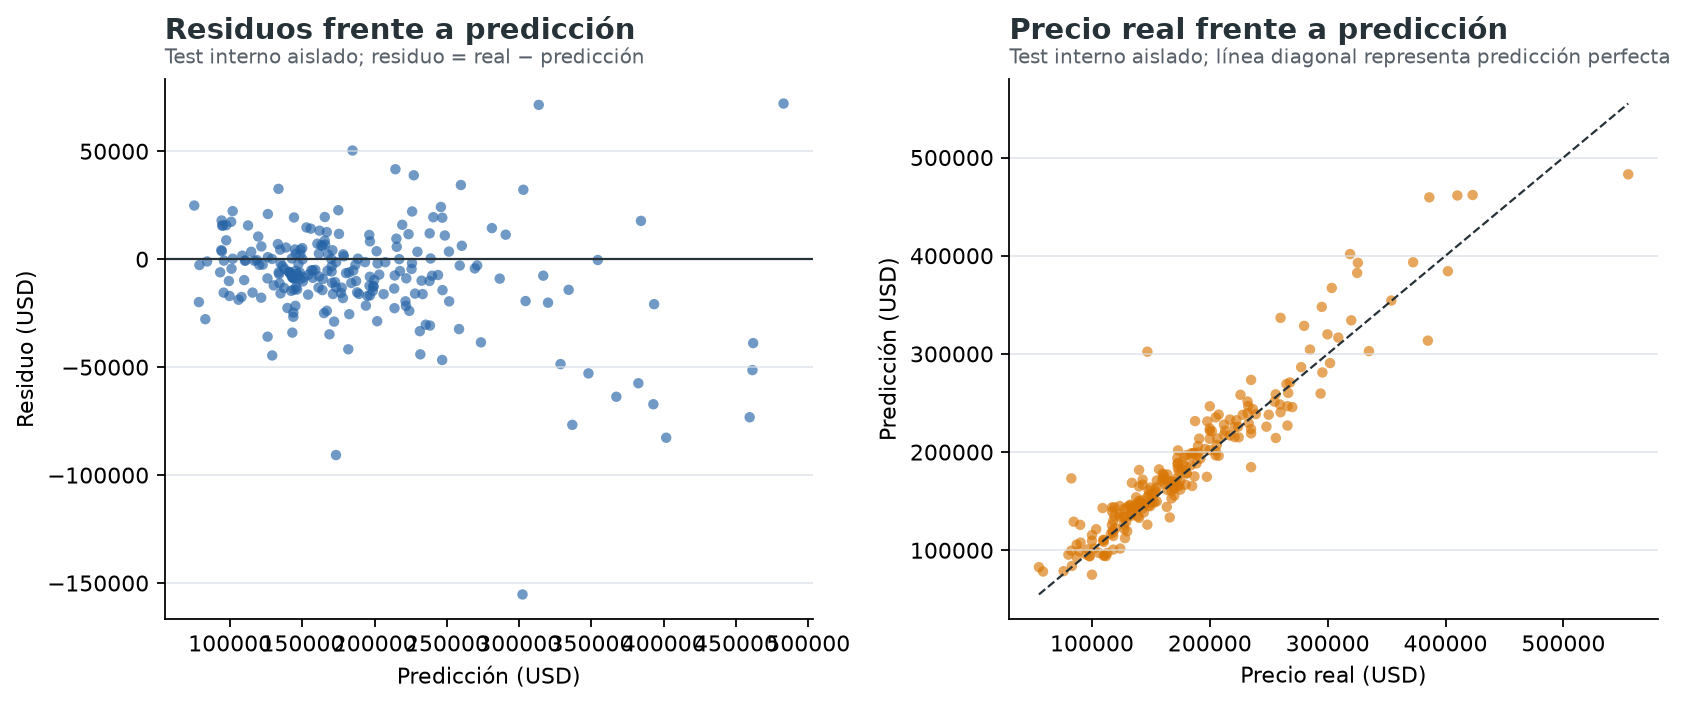

,Viviendas,RMSE,MAE,Sesgo_medio
PriceQuartile,,,,
Q1,61,"19,338","13,392","-7,349"
Q2,56,"24,701","13,195","-10,382"
Q3,58,"16,853","13,163","-5,931"
Q4,59,"33,585","24,669","-6,072"


,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,SalePrice,PredictionSingle,ResidualSingle,AbsoluteError
0,1325,Somerst,8,1795,2006,"147,000","302,281","-155,281","155,281"
1,633,NWAmes,7,1411,1977,"82,500","173,217","-90,717","90,717"
2,596,StoneBr,8,1826,2005,"319,000","401,691","-82,691","82,691"
3,319,NoRidge,7,2646,1993,"260,000","336,730","-76,730","76,730"
4,225,NridgHt,10,2392,2003,"386,250","459,459","-73,209","73,209"
5,441,NridgHt,10,2402,2008,"555,000","482,904","72,096","72,096"
6,54,Veenker,9,1842,1981,"385,000","313,514","71,486","71,486"
7,168,NridgHt,8,2161,2007,"325,624","392,815","-67,191","67,191"
8,876,Somerst,8,2610,2007,"303,477","367,190","-63,713","63,713"
9,584,OldTown,10,2775,1893,"325,000","382,456","-57,456","57,456"


In [6]:
display(pd.DataFrame(final_metrics["internal_test"]).T[["rmse", "mae", "r2"]].style.format({"rmse": "{:,.0f}", "mae": "{:,.0f}", "r2": "{:.3f}"}))
display(Image(filename=str(FIGURES / "residuals.png")))
errors = pd.read_csv(RESULTS / "internal_test_predictions.csv")
errors["AbsoluteError"] = errors["ResidualSingle"].abs()
errors["PriceQuartile"] = pd.qcut(errors["SalePrice"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
quartiles = errors.groupby("PriceQuartile", observed=True).apply(lambda part: pd.Series({
    "Viviendas": len(part),
    "RMSE": np.sqrt(np.mean((part["SalePrice"] - part["PredictionSingle"]) ** 2)),
    "MAE": np.mean(np.abs(part["SalePrice"] - part["PredictionSingle"])),
    "Sesgo_medio": np.mean(part["SalePrice"] - part["PredictionSingle"]),
}), include_groups=False)
display(quartiles.style.format({"Viviendas": "{:.0f}", "RMSE": "{:,.0f}", "MAE": "{:,.0f}", "Sesgo_medio": "{:,.0f}"}))
details = data[["Id", "Neighborhood", "OverallQual", "GrLivArea", "YearBuilt"]]
display(errors.nlargest(10, "AbsoluteError").merge(details, on="Id")[["Id", "Neighborhood", "OverallQual", "GrLivArea", "YearBuilt", "SalePrice", "PredictionSingle", "ResidualSingle", "AbsoluteError"]].style.format({
    "SalePrice": "{:,.0f}", "PredictionSingle": "{:,.0f}", "ResidualSingle": "{:,.0f}", "AbsoluteError": "{:,.0f}"
}))


## 2.5 Conclusiones

1. El mejor MLP individual alcanzó **USD 24,460 de RMSE interno** sin usar el test para seleccionar hiperparámetros.
2. El ensemble mejoró el RMSE interno frente al modelo individual; su uso queda condicionado a las reglas del profesor.
3. Las decisiones con mayor rigor son el ajuste de transformadores por fold, la evaluación final única y la persistencia conjunta de preprocesador, target y pesos.
4. Las limitaciones principales son el tamaño muestral, categorías raras y sensibilidad de RMSE a viviendas extremas.


## 2.6 Enlace al repositorio de GitHub

[Repositorio Proyecto1DeepLearning](https://github.com/iancumes/Proyecto1DeepLearning)

El README documenta instalación y ejecución. `train.csv` no se publica: debe colocarse en la raíz y coincidir con la huella registrada.


## Takeaways y reproducibilidad

El comando `python scripts/run_pipeline.py --data train.csv --budget-minutes 75 --seed 23236` reconstruye los artefactos. Para el día de competencia, coloque `pipeline_test.csv` en la raíz y ejecute `python scripts/predict.py`; la salida oficial tendrá exactamente `Id,Prediction`. `expected_output.csv` es un template opcional y `--model ensemble` queda como alternativa autorizada.
